# 🚀 3강. MediaPipe 소개 — 구글의 사전학습 온디바이스 인식 모델 — 정답

> 📌 **이 노트북의 목표**
> - 손 랜드마크(HandLandmarker) 검출을 직접 돌려보고, 물체 인식(ObjectDetector)까지 두 번째 태스크로 확장한다.
> - IMAGE·VIDEO·LIVE_STREAM 세 실행 모드의 차이를 API 레벨에서 직접 확인한다.
> - `mp.solutions`(레거시) → Tasks API(현재)로 바뀐 실제 버전 함정을 코드로 재현한다.

**공식 저장소**
- [google-ai-edge/mediapipe](https://github.com/google-ai-edge/mediapipe) — 현재 공식 GitHub (과거 `google/mediapipe`에서 이관)
- [공식 문서(개발자 가이드)](https://developers.google.com/mediapipe/solutions) · [Tasks API 레퍼런스](https://developers.google.com/mediapipe/solutions/tasks)
- [모델 카드/다운로드](https://developers.google.com/mediapipe/solutions/vision/hand_landmarker#models)

이 노트북은 이 폴더의 `sample_hand.png`(합성 렌더, 저작권 문제 없음)로 손 검출을 실습합니다.

## 목차
1. 설치
2. 기본 작동 방법 — Hand Landmarker · Object Detector · 3가지 실행 모드
3. 특징 정리
4. 🤝 AI Pair 섹션


## 1. 설치

패키지 이름은 `mediapipe`입니다.

> **버전 주의**: mediapipe는 버전이 오르며 API가 크게 바뀐 이력이 있습니다. 예전 자료에서
> 흔히 보이는 `mp.solutions.hands` 같은 코드는 **1.0.0부터 완전히 제거**됐습니다(레거시
> API 자체가 삭제, deprecated가 아니라 import 자체가 실패합니다). 지금은 `mediapipe.tasks`
> 아래의 **Tasks API**(`HandLandmarker`, `ObjectDetector`, `FaceLandmarker` 등)만 지원합니다.


In [1]:
%pip install -q mediapipe

Note: you may need to restart the kernel to use updated packages.


In [2]:
import mediapipe as mp

print("mediapipe 버전:", mp.__version__)
print("mp.solutions 존재 여부:", hasattr(mp, "solutions"))


mediapipe 버전: 1.0.0
mp.solutions 존재 여부: False


버전 1.0.0에서는 `mp.solutions`가 아예 없습니다 — 오래된 튜토리얼을 그대로 따라 하면
`ModuleNotFoundError: No module named 'mediapipe.solutions'`를 만납니다.

## 2. 기본 작동 방법

### 2.1 태스크 1 — Hand Landmarker

Tasks API의 공통 흐름입니다.

```
모델 파일(.task) 다운로드  →  Landmarker 옵션 설정 → 생성  →  이미지에 detect()  →  결과 해석
```

MediaPipe는 YOLO처럼 이름만 주면 자동 다운로드되지 않습니다 — `.task` 모델 파일을
직접 받아와야 합니다(공식 배포 URL, [모델 목록](https://developers.google.com/mediapipe/solutions/vision/hand_landmarker#models)).


In [3]:
import urllib.request
import os

MODEL_URL = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
urllib.request.urlretrieve(MODEL_URL, "hand_landmarker.task")
print("모델 파일 크기:", os.path.getsize("hand_landmarker.task"), "bytes  (~7.8 MB)")


모델 파일 크기: 7819105 bytes  (~7.8 MB)


In [4]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

base_options = python.BaseOptions(model_asset_path="hand_landmarker.task")
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

mp_image = mp.Image.create_from_file("sample_hand.png")
result = detector.detect(mp_image)

print("검출된 손 개수:", len(result.hand_landmarks))


검출된 손 개수: 1


I0000 00:00:1785468913.797626 1793931 init-domain.cc:132] Fiber init: default domain = pthread, concurrency = 13, prefix = pthread-default
I0000 00:00:1785468913.903741 1793931 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1785468913.919884 1793933 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468913.932633 1793933 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468913.983573 1793941 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


한 손당 **21개 랜드마크**가 나오고, 각 랜드마크는 순서(인덱스)가 고정되어 있습니다
(0=손목, 4=엄지 끝, 8=검지 끝 …). "이 점이 엄지 끝이다"까지 아는 것이 OpenCV의 컨투어와
결정적으로 다른 점입니다.


In [5]:
hand = result.hand_landmarks[0]
handedness = result.handedness[0][0]

print("랜드마크 개수:", len(hand))
print(f"손잡이(handedness): {handedness.category_name} (확신도 {handedness.score:.2f})")
print(f"0번 손목:    x={hand[0].x:.3f} y={hand[0].y:.3f}")
print(f"4번 엄지 끝:  x={hand[4].x:.3f} y={hand[4].y:.3f}")
print(f"8번 검지 끝:  x={hand[8].x:.3f} y={hand[8].y:.3f}")
print("\n(x, y는 이미지 크기에 대한 0~1 비율 좌표 — 이미지 해상도가 달라도 그대로 쓸 수 있다)")


랜드마크 개수: 21
손잡이(handedness): Right (확신도 0.96)
0번 손목:    x=0.545 y=0.688
4번 엄지 끝:  x=0.321 y=0.225
8번 검지 끝:  x=0.344 y=0.263

(x, y는 이미지 크기에 대한 0~1 비율 좌표 — 이미지 해상도가 달라도 그대로 쓸 수 있다)


`mp.solutions.drawing_utils`도 1.0.0에서 함께 제거됐으므로, 21개 점과 연결선을 직접
`cv2`로 그립니다 — 어느 점이 어느 점과 이어지는지는 MediaPipe 공식 문서의 손 랜드마크
토폴로지를 그대로 씁니다.


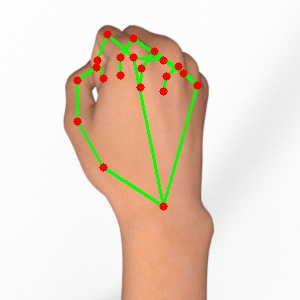

In [6]:
import cv2

img = cv2.imread("sample_hand.png")
h, w = img.shape[:2]

HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),            # 엄지
    (0, 5), (5, 6), (6, 7), (7, 8),            # 검지
    (5, 9), (9, 10), (10, 11), (11, 12),       # 중지
    (9, 13), (13, 14), (14, 15), (15, 16),     # 약지
    (13, 17), (17, 18), (18, 19), (19, 20),    # 소지
    (0, 17),                                    # 손목 - 소지 밑동
]

points = [(int(lm.x * w), int(lm.y * h)) for lm in hand]
for a, b in HAND_CONNECTIONS:
    cv2.line(img, points[a], points[b], (0, 255, 0), 2)
for x, y in points:
    cv2.circle(img, (x, y), 4, (0, 0, 255), -1)

cv2.imwrite("landmarks_result.jpg", img)
from IPython.display import Image, display
display(Image(filename="landmarks_result.jpg"))


### 2.2 태스크 2 — Object Detector (같은 사진, 다른 태스크)

Hand Landmarker와 완전히 다른 대상(일상 사물)을 검출하지만, **코드 구조는 동일**합니다 —
`BaseOptions` → `XxxOptions` → `create_from_options()` → `detect()`. 이번엔 손이 아니라
1강·2강에서 계속 쓴 버스 사진에 돌려서, YOLO와 정확히 같은 사진을 MediaPipe로도 검출해 봅니다.


In [7]:
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "bus.jpg")
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/object_detector/efficientdet_lite0/float32/latest/efficientdet_lite0.tflite",
    "efficientdet_lite0.tflite",
)
print("EfficientDet-Lite0 모델 크기:", os.path.getsize("efficientdet_lite0.tflite"), "bytes  (~13.8 MB)")

obj_options = vision.ObjectDetectorOptions(
    base_options=python.BaseOptions(model_asset_path="efficientdet_lite0.tflite"),
    score_threshold=0.3,
)
obj_detector = vision.ObjectDetector.create_from_options(obj_options)

bus_image = mp.Image.create_from_file("bus.jpg")
obj_result = obj_detector.detect(bus_image)

print("검출된 물체 수:", len(obj_result.detections))
for d in obj_result.detections:
    cat = d.categories[0]
    box = d.bounding_box
    print(f"{cat.category_name:12s} conf={cat.score:.2f} box=({box.origin_x},{box.origin_y},{box.width},{box.height})")


EfficientDet-Lite0 모델 크기: 13836895 bytes  (~13.8 MB)
검출된 물체 수: 4
bus          conf=0.82 box=(6,217,776,536)
person       conf=0.76 box=(45,383,178,522)
person       conf=0.74 box=(225,401,128,459)
person       conf=0.53 box=(679,329,133,557)


I0000 00:00:1785468915.306945 1794070 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro


**2강(YOLO)은 같은 사진에서 사람 4명 전부**(신뢰도 0.62까지)를 잡았는데, MediaPipe는 **3명만**
(임계값 0.3 기준) 잡았습니다 — 가장 낮은 신뢰도였던 사람이 여기서는 임계값 미달로 빠졌습니다.
"어느 쪽이 더 낫다"가 아니라, **모델·임계값 설정에 따라 같은 사진도 다른 결과**를 낸다는
실측 비교입니다.


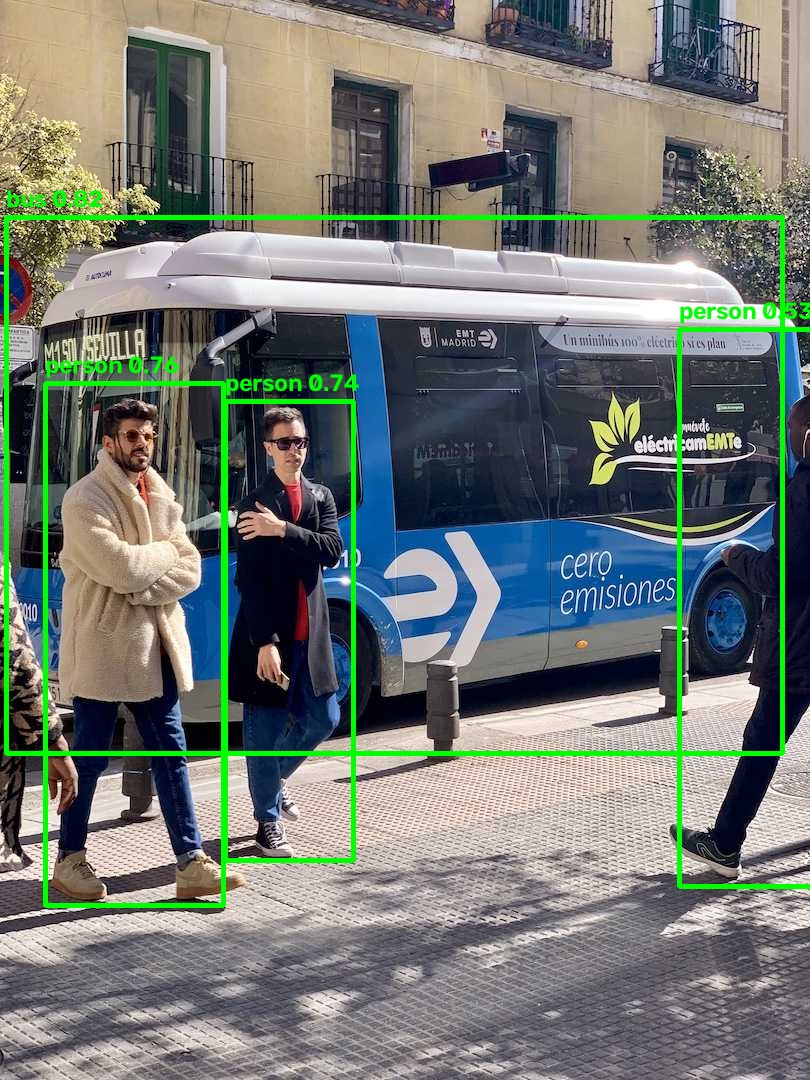

In [8]:
drawn = cv2.imread("bus.jpg")
for d in obj_result.detections:
    cat = d.categories[0]
    b = d.bounding_box
    x1, y1 = b.origin_x, b.origin_y
    x2, y2 = x1 + b.width, y1 + b.height
    cv2.rectangle(drawn, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(drawn, f"{cat.category_name} {cat.score:.2f}", (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
cv2.imwrite("objdet_result.jpg", drawn)
display(Image(filename="objdet_result.jpg"))


### 2.3 세 가지 실행 모드 — IMAGE / VIDEO / LIVE_STREAM

지금까지 쓴 `detect()`는 **IMAGE 모드**(기본값, 정지 이미지 1장씩 독립 처리)입니다. 실제
웹캠·영상에서는 이전 프레임 정보를 재사용하는 VIDEO 모드가 유리합니다(3강 실습에서 다룬
"손이 있을 때만 이득"이 이 모드입니다).

| 모드 | 메서드 | 용도 |
|---|---|---|
| `IMAGE` (기본값) | `detect()` | 정지 이미지 1장 — 지금까지 쓴 것 |
| `VIDEO` | `detect_for_video(image, timestamp_ms)` | 저장된 영상 파일, 타임스탬프로 프레임 간 트래킹 최적화 |
| `LIVE_STREAM` | `detect_async(image, timestamp_ms)` + 콜백 | 웹캠 실시간, 비동기 처리 |


In [9]:
video_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=vision.RunningMode.VIDEO,   # IMAGE 대신 VIDEO로 전환
    num_hands=1,
)
video_detector = vision.HandLandmarker.create_from_options(video_options)

# 실제 영상이 아니라 같은 정지 이미지로 API 호출만 확인 — timestamp_ms는 반드시 단조 증가해야 함
video_result = video_detector.detect_for_video(mp_image, 0)
print("VIDEO 모드 detect_for_video() 정상 동작, 검출 손 개수:", len(video_result.hand_landmarks))


I0000 00:00:1785468915.491017 1794092 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1785468915.497307 1794097 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468915.504756 1794097 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


VIDEO 모드 detect_for_video() 정상 동작, 검출 손 개수: 1


### 3.3 다양한 인식 태스크(Tasks API)

| 태스크 | 클래스 | 인식 대상 |
|---|---|---|
| 손 | `HandLandmarker` | 21개 손 랜드마크 — 이번에 직접 실행함 |
| 사물 | `ObjectDetector` | COCO 계열 사전학습 사물 탐지(경량) — 이번에 직접 실행함 |
| 얼굴 | `FaceLandmarker` | 얼굴 468개 랜드마크(눈·코·입 등) |
| 몸 전체 자세 | `PoseLandmarker` | 33개 전신 관절 랜드마크 |
| 제스처 | `GestureRecognizer` | 미리 정의된 손 제스처(엄지척 등) 직접 분류 |
| 이미지 분할 | `ImageSegmenter` | 픽셀 단위 배경/전경 분리 |

[Tasks 전체 목록](https://developers.google.com/mediapipe/solutions/vision)

### 3.4 3가지 실행 모드
IMAGE(정지 이미지) · VIDEO(타임스탬프 기반 트래킹 최적화) · LIVE_STREAM(웹캠, 비동기 콜백) —
이번에 IMAGE·VIDEO 둘 다 API 레벨로 직접 확인했습니다.

### 3.5 온디바이스 경량 모델
손 검출 모델은 7.8MB, 사물 검출 모델(EfficientDet-Lite0)은 13.8MB입니다. YOLO11x(114.4MB)보다
훨씬 가볍고, 모바일에서도 실시간으로 돕니다.

### 3.6 실전 활용 사례 — Physical AI/로보틱스에서는?

**MediaPipe도 physical AI(로보틱스)에 실제로 쓰입니다 — 단, "로봇의 두뇌"가 아니라 인지(perception)
레이어의 경량 부품으로서입니다.** 오늘 실행한 바로 그 `HandLandmarker`가 사람의 손 동작을 실시간으로
읽어 로봇 팔을 원격조작(teleoperation)하거나 사람-로봇 상호작용(HRI)에 넘기는 입력으로 쓰이는
사례가 많습니다 — ROS2와 MediaPipe를 결합하는 공식 튜토리얼도 있습니다.

다만 "NVIDIA 계열 모델이 physical AI에서 더 앞서 있다"는 것도 맞는 말입니다 — 둘은 층위 자체가
다릅니다. NVIDIA의 Cosmos(world foundation model)·Isaac GR00T(vision-language-action 모델)는
로봇이 스스로 상황을 이해하고 다단계 행동을 생성하는 훨씬 상위 계층을 다룹니다. MediaPipe는
그 파이프라인에 들어갈 "사람 동작을 읽는" 좁고 가벼운 인지 컴포넌트 하나일 뿐입니다 — 2강(YOLO)의
자율주행 사례와 같은 구도로, "이 좁은 문제엔 적합한 경량 도구"와 "훨씬 큰 상위 스택"을 같은
저울에 올리고 비교할 수는 없습니다.

## 4. 🤝 AI Pair 섹션 — MediaPipe 코드, AI와 함께 검증하기

### 1️⃣ Solo — 직접 작성해 보세요

`ObjectDetectorOptions`의 `score_threshold`를 `0.3`에서 `0.6`으로 올리면 검출 개수가 어떻게
바뀌는지 직접 실행해 확인해 보세요.

In [10]:
obj_options_strict = vision.ObjectDetectorOptions(
    base_options=python.BaseOptions(model_asset_path="efficientdet_lite0.tflite"),
    score_threshold=0.6,
)
strict_detector = vision.ObjectDetector.create_from_options(obj_options_strict)
strict_result = strict_detector.detect(bus_image)
print(len(strict_result.detections))  # conf=0.53인 사람 1명이 빠져 3개로 줄어든다


3


I0000 00:00:1785468915.582039 1794116 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro


### 2️⃣ Review

아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.

```text
MediaPipe Tasks API의 IMAGE, VIDEO, LIVE_STREAM 세 running_mode 차이를 설명해주세요.
저장된 mp4 파일을 프레임 단위로 순회하며 손을 추적하는 코드를 짤 때 어느 모드를 써야 하고,
timestamp_ms 인자를 어떻게 계산해서 넘겨야 하는지도 알려주세요.
```

### 3️⃣ Debug — "조용히 틀린" 코드 찾기

아래는 **실행은 되고 에러도 안 나지만, 손이 없는데도 계속 무언가를 검출한 것처럼 나오는**
코드입니다. 결함을 찾아 고치세요.


In [11]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 result.hand_landmarks 길이 확인을 빼먹었습니다.
buggy_detector = vision.HandLandmarker.create_from_options(
    vision.HandLandmarkerOptions(base_options=python.BaseOptions(model_asset_path="hand_landmarker.task"), num_hands=1)
)
buggy_result = buggy_detector.detect(mp_image)
first_hand = buggy_result.hand_landmarks[0]   # <- 여기가 의심 지점
print("첫 번째 손의 엄지 좌표:", first_hand[4].x, first_hand[4].y)


첫 번째 손의 엄지 좌표: 0.32071465253829956 0.22455433011054993


I0000 00:00:1785468915.701451 1794186 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1785468915.709730 1794208 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1785468915.722018 1794208 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


💭 **생각해 볼 점**:
- 이번엔 손이 있는 이미지라 우연히 동작했지만, `result.hand_landmarks`가 **빈 리스트**인
  이미지(손이 없는 사진)에 이 코드를 그대로 쓰면 `IndexError: list index out of range`로
  죽습니다.
- 실전에서는 항상 `if len(result.hand_landmarks) > 0:`으로 먼저 확인해야 합니다 — 이 워크샵의
  `mediapipe1_hand_lite`가 매번 `len(hands) == 1`을 검사하는 이유이기도 합니다.
- "지금 당장은 에러가 안 난다"가 "이 코드가 맞다"를 보장하지 않는다는 걸 보여주는 사례입니다.

### 4️⃣ Prompt Card

```text
1. "MediaPipe HandLandmarker와 YOLO11-pose(사람 자세 추정)는 둘 다 관절/랜드마크를 찾는데
   무엇이 근본적으로 다른지" 먼저 예측한 뒤 AI에게 근거를 물어 검증하세요.
2. "score_threshold를 낮추면 재현율(recall)과 정밀도(precision)가 각각 어느 방향으로
   움직이는지"를 AI에게 설명받고, 이번 노트북의 0.3→0.6 실험 결과와 맞는지 확인해보세요.
3. "GestureRecognizer로 직접 제스처를 인식하는 것과, HandLandmarker 좌표로 내가 직접 if문
   규칙을 짜는 것(이 워크샵의 mediapipe1_hand_lite 방식) 중 언제 어느 쪽이 나은지"를
   AI에게 물어 트레이드오프를 정리해보세요.
```

---
## 📚 [세션 요약] MediaPipe 소개

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: 범용 대상(손·얼굴·몸·일상사물)은 구글이 이미 학습해 배포한 모델을 그대로 쓴다 — 내가 학습시킬 필요가 없다.
> 2. **실무적 활용**: `BaseOptions → XxxOptions → create_from_options() → detect()` 패턴 하나로 HandLandmarker·ObjectDetector 등 모든 태스크를 다룬다. VIDEO/LIVE_STREAM 모드는 실시간 처리에 최적화되어 있다.
> 3. **한계와 대응**: `mp.solutions` 레거시 API는 1.0.0에서 완전히 제거됐다 — 최신 버전 기준 Tasks API로 짜야 하고, 빈 검출 결과(`hand_landmarks == []`)를 항상 방어적으로 확인해야 한다.
> 4. **다음 강의 예고**: 4강에서는 1~3강에서 배운 OpenCV·YOLO·MediaPipe를 같은 과제(가위바위보)로 직접 종합 비교합니다.
